# ¿Se pueden comprar los puntos?
## Gasto, salarios y rendimiento en la Premier League (4 temporadas: 22/23 → 25/26)

**Tecnicatura Universitaria en Gestión y Análisis de Datos en Organizaciones — FCE UBA**
Trabajo Práctico Grupal · 1er Cuatrimestre 2026

---
**Integrantes:** _(completar: nombre, n° de registro y usuario de GitHub de cada uno)_
**Repositorio:** _(completar link)_

---

### Resumen
Analizamos la relación entre el **gasto de los clubes** (salarios + fichajes) y su **rendimiento**
(puntos) en la Premier League a lo largo de **cuatro temporadas (2022/23 a 2025/26)**. La base permite
algo poco común: un **panel balanceado de 17 clubes presentes en las cuatro temporadas**, lo que hace
el análisis mucho más robusto. Estudiamos qué pesa más (¿salarios o fichajes?), cómo evolucionó el
"precio del punto" y un fenómeno llamativo del período: en **2023/24 y 2024/25 los tres equipos
ascendidos descendieron**, dejando intacto el núcleo de 17 — la *trampa de los ascendidos*. Se aplican
conceptos de la materia (elasticidad, función de costo, rendimientos decrecientes, margen/rentabilidad).

> **Sobre el uso de IA.** Notebook elaborado con asistencia de un modelo (Claude) para estructura,
> código y redacción; la interpretación es del grupo. Celdas con asistencia directa: `# [IA] Prompt: ...`.

## 0. Configuración del entorno
> El notebook **carga la base directamente desde el repositorio de GitHub del grupo** (no hace falta
> subir nada a mano). Si por algún motivo no puede acceder a GitHub, usa como respaldo un archivo local
> con el mismo nombre en la sesión.

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os, warnings
import sympy as sp          # derivadas simbólicas (1ra y 2da) para la optimización
import pulp                 # programación lineal para asignar el presupuesto
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 150)
plt.rcParams.update({"figure.dpi":120,"figure.facecolor":"white","axes.facecolor":"#fbfbfd",
    "axes.grid":True,"grid.color":"#e5e7eb","grid.alpha":0.9,"axes.spines.top":False,
    "axes.spines.right":False,"axes.titlesize":13,"axes.titleweight":"bold","font.size":11})
AZUL="#2563eb"; VIOLETA="#7c3aed"; VERDE="#16a34a"; ROJO="#dc2626"; NARANJA="#f59e0b"; GRIS="#64748b"

def etiquetar_barras_h(ax, valores, fmt="{:.1f}", sufijo=""):
    '''Escribe el valor al final de cada barra horizontal.'''
    for i, v in enumerate(valores):
        ax.text(v, i, "  "+fmt.format(v)+sufijo, va="center", ha="left", fontsize=8.5, color="#111827")

# Fuente de datos: repositorio de GitHub del grupo (raw). El notebook la baja sola.
URL_GITHUB = "https://raw.githubusercontent.com/nicotucci/TP-Laboratorio-AnalisisFutbol/main/Datasets/base_scouting_completa.xlsx"
ARCHIVO_LOCAL = "base_scouting_actualizada_2.xlsx"   # respaldo local (misma base, por si falla GitHub)
SEAS = {"22":"22/23", "23":"23/24", "24":"24/25", "25":"25/26"}   # las 4 temporadas del panel
os.makedirs("figuras", exist_ok=True)
print("Fuente principal:", URL_GITHUB)

Fuente principal: https://raw.githubusercontent.com/nicotucci/TP-Laboratorio-AnalisisFutbol/main/Datasets/base_scouting_completa.xlsx


## 1. Carga y exploración inicial  *(consigna 3.1)*
### 1.a) Carga y vista de las primeras/últimas filas

In [ ]:
# [IA] Prompt: "Cargá la base desde la URL raw de GitHub; si el archivo no tiene las 4 temporadas
#               (falta Detalle_Traspasos_25) o falla la descarga, usá el archivo local de respaldo."
def cargar_base():
    # 1) intento desde el repositorio de GitHub
    try:
        xls = pd.ExcelFile(URL_GITHUB)
        if "Detalle_Traspasos_25" in xls.sheet_names:      # validación: ¿es la base de 4 temporadas?
            print("✓ Base cargada desde GitHub.")
            return xls
        print("⚠ El archivo del repo es una versión vieja (sin temporadas 23/24/25). Uso el respaldo local.")
    except Exception as e:
        print("⚠ No se pudo leer desde GitHub:", str(e)[:80], "→ uso el respaldo local.")
    # 2) respaldo: archivo local en la sesión
    return pd.ExcelFile(ARCHIVO_LOCAL)

xls = cargar_base()
print("Hojas:", xls.sheet_names)
hojas = {h: pd.read_excel(xls, sheet_name=h) for h in xls.sheet_names}
maestro = hojas["Maestro_Clubes"]
print("\n.head():"); display(maestro.head())
print(".tail():"); display(maestro.tail())

✓ Base cargada desde GitHub.
Hojas: ['Maestro_Clubes', 'Detalle_Traspasos_21', 'Detalle_Traspasos_22', 'LIGAS_INFO', 'ESTADISTICAS_21', 'ESTADISTICAS_22', 'Detalle_Traspasos_23', 'Detalle_Traspasos_24', 'Detalle_Traspasos_25']

.head():


,CLUBES,CONTRATOS_21,SALARIOS_AÑO_21,CONTRATOS_22,SALARIOS_AÑO_22,PUNTOS_21,PUNTOS_22,INGRESOS_FICHAJES_21_M$,INGRESOS_FICHAJES_22_M$,GASTOS_FICHAJES_21_M$,GASTOS_FICHAJES_22_M$,BALANCE_21_M$,BALANCE_22_M$,CONTRATOS_23,SALARIOS_AÑO_23,CONTRATOS_24,SALARIOS_AÑO_24,CONTRATOS_25,SALARIOS_AÑO_25,PUNTOS_23,PUNTOS_24,PUNTOS_25,INGRESOS_FICHAJES_23_M$,INGRESOS_FICHAJES_24_M$,INGRESOS_FICHAJES_25_M$,GASTOS_FICHAJES_23_M$,GASTOS_FICHAJES_24_M$,GASTOS_FICHAJES_25_M$,BALANCE_23_M$,BALANCE_24_M$,BALANCE_25_M$
0,ARSENAL,70.0,"$138,984,848",69,"$129,210,591",69.0,84,34.54,26.18,184.14,205.04,-149.60,-178.86,30.0,"$200,500,000",31.0,"$225,000,000",32.0,"$290,000,000",89.0,74.0,85.0,33.02,57.15,0.0,293.37,127.00,391.96,-260.35,-69.85,-391.96
1,ASTON VILLA,66.0,"$86,876,165",81,"$127,888,743",45.0,61,139.70,59.40,142.78,124.30,-3.08,-64.90,29.0,"$130,000,000",32.0,"$170,000,000",33.0,"$195,000,000",68.0,66.0,65.0,0.00,0.00,0.0,124.46,109.22,66.00,-124.46,-109.22,-66.00
2,BRENTFORD,90.0,"$25,677,627",75,"$40,845,084",46.0,59,1.10,3.96,42.02,54.18,-40.92,-50.22,28.0,"$56,000,000",27.0,"$62,000,000",27.0,"$68,000,000",39.0,56.0,53.0,0.00,0.00,198.0,57.40,30.48,59.40,-57.40,-30.48,138.60
3,BRIGHTON,76.0,"$56,471,332",73,"$48,776,174",51.0,62,86.68,152.24,83.14,61.27,3.54,90.97,29.0,"$90,000,000",30.0,"$105,000,000",30.0,"$115,000,000",48.0,61.0,53.0,171.45,22.86,0.0,48.26,66.04,0.00,123.19,-43.18,0.00
4,BURNLEY,72.0,"$48,025,544",0,0,35.0,0,44.55,0.00,54.34,0.00,-9.79,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


.tail():


,CLUBES,CONTRATOS_21,SALARIOS_AÑO_21,CONTRATOS_22,SALARIOS_AÑO_22,PUNTOS_21,PUNTOS_22,INGRESOS_FICHAJES_21_M$,INGRESOS_FICHAJES_22_M$,GASTOS_FICHAJES_21_M$,GASTOS_FICHAJES_22_M$,BALANCE_21_M$,BALANCE_22_M$,CONTRATOS_23,SALARIOS_AÑO_23,CONTRATOS_24,SALARIOS_AÑO_24,CONTRATOS_25,SALARIOS_AÑO_25,PUNTOS_23,PUNTOS_24,PUNTOS_25,INGRESOS_FICHAJES_23_M$,INGRESOS_FICHAJES_24_M$,INGRESOS_FICHAJES_25_M$,GASTOS_FICHAJES_23_M$,GASTOS_FICHAJES_24_M$,GASTOS_FICHAJES_25_M$,BALANCE_23_M$,BALANCE_24_M$,BALANCE_25_M$
18,WEST HAM,77.0,"$90,602,030",69,"$104,756,412",56.0,40,4.66,23.71,81.95,216.26,-77.30,-192.56,29.0,"$115,000,000",28.0,"$120,000,000",27.0,"$125,000,000",52.0,43.0,39.0,196.85,0.00,0.00,152.40,152.40,26.4,44.45,-152.40,-26.40
19,WOLVES,76.0,"$69,595,717",88,"$66,323,698",51.0,41,34.98,71.36,41.36,197.46,-6.38,-126.10,27.0,"$78,000,000",26.0,"$82,000,000",25.0,"$88,000,000",46.0,40.0,20.0,139.70,119.38,132.44,46.99,80.01,0.0,92.71,39.37,132.44
20,BOURNEMOUTH,NaN,NaN,28,"$64,000,000",NaN,39,NaN,0.00,NaN,44.34,NaN,-44.34,27.0,"$72,000,000",27.0,"$82,000,000",28.0,"$95,000,000",48.0,56.0,57.0,76.20,0.00,0.00,77.47,53.59,26.4,-1.27,-53.59,-26.40
21,FULHAM,NaN,NaN,27,"$83,000,000",NaN,52,NaN,8.98,NaN,108.95,NaN,-99.97,27.0,"$95,000,000",28.0,"$102,000,000",27.0,"$112,000,000",47.0,54.0,52.0,63.50,0.00,0.00,75.18,84.07,0.0,-11.68,-84.07,0.00
22,NOTTINGHAM FOREST,NaN,NaN,33,"$115,000,000",NaN,38,NaN,6.41,NaN,143.73,NaN,-137.32,30.0,"$98,000,000",31.0,"$115,000,000",30.0,"$145,000,000",32.0,65.0,44.0,0.00,0.00,0.00,98.55,41.14,72.6,-98.55,-41.14,-72.60


### 1.b) Estructura, dimensiones, tipos y cobertura

In [ ]:
print("Dimensiones por hoja:")
for h, df in hojas.items(): print(f"  {h:<22} {df.shape}")
pts_cols = [c for c in maestro.columns if c.startswith("PUNTOS_")]
print("\nTemporadas con datos de puntos:", pts_cols, "(sufijos 21..25 = 2021/22..2025/26)")
print("Clubes por temporada (con puntos>0):")
for c in pts_cols:
    print(f"  {c}: {(pd.to_numeric(maestro[c],errors='coerce').fillna(0)>0).sum()} clubes")
print("\nTipos de dato (.dtypes), primeras columnas:"); print(maestro.dtypes.head(8))

Dimensiones por hoja:
  Maestro_Clubes         (23, 31)
  Detalle_Traspasos_21   (280, 7)
  Detalle_Traspasos_22   (387, 7)
  LIGAS_INFO             (5, 5)
  ESTADISTICAS_21        (537, 282)
  ESTADISTICAS_22        (550, 282)
  Detalle_Traspasos_23   (118, 7)
  Detalle_Traspasos_24   (85, 7)
  Detalle_Traspasos_25   (70, 7)

Temporadas con datos de puntos: ['PUNTOS_21', 'PUNTOS_22', 'PUNTOS_23', 'PUNTOS_24', 'PUNTOS_25'] (sufijos 21..25 = 2021/22..2025/26)
Clubes por temporada (con puntos>0):
  PUNTOS_21: 20 clubes
  PUNTOS_22: 20 clubes
  PUNTOS_23: 17 clubes
  PUNTOS_24: 17 clubes
  PUNTOS_25: 17 clubes

Tipos de dato (.dtypes), primeras columnas:
CLUBES                      object
CONTRATOS_21               float64
SALARIOS_AÑO_21             object
CONTRATOS_22                 int64
SALARIOS_AÑO_22             object
PUNTOS_21                  float64
PUNTOS_22                    int64
INGRESOS_FICHAJES_21_M$    float64
dtype: object


### 1.c) Calidad: nulos, duplicados, descriptivos y el núcleo de 17 clubes

In [ ]:
print("Nulos y duplicados por hoja:")
for h, df in hojas.items():
    print(f"  {h:<22} nulos={int(df.isnull().sum().sum()):>5}  duplicados={int(df.duplicated().sum())}")

# Identificar los clubes presentes en las 4 temporadas 22..25
def en_liga(yr): return pd.to_numeric(maestro[f"PUNTOS_{yr}"], errors="coerce").fillna(0) > 0
mask_core = en_liga("22") & en_liga("23") & en_liga("24") & en_liga("25")
CORE = maestro.loc[mask_core, "CLUBES"].tolist()
print(f"\n>> Núcleo estable: {len(CORE)} clubes presentes en las 4 temporadas 22/23–25/26:")
print("  ", ", ".join(c.title() for c in CORE))

print("\n>> Problemas de calidad detectados:")
print("   1) SALARIOS como texto:", repr(maestro['SALARIOS_AÑO_22'].iloc[0]))
print("   2) Detalle_Traspasos_22 sin encabezado y con columnas en otro orden (Posición/Tipo intercambiados).")
print("   3) Temporadas 21/22 y 22/23 tienen 20 clubes; 23/24–25/26 tienen 17 (los ascendidos descendieron).")
display(maestro[["PUNTOS_22","PUNTOS_23","PUNTOS_24","PUNTOS_25",
                 "GASTOS_FICHAJES_22_M$","GASTOS_FICHAJES_25_M$"]].describe().round(1))

Nulos y duplicados por hoja:
  Maestro_Clubes         nulos=  126  duplicados=0
  Detalle_Traspasos_21   nulos=    0  duplicados=0
  Detalle_Traspasos_22   nulos=    0  duplicados=1
  LIGAS_INFO             nulos=    0  duplicados=0
  ESTADISTICAS_21        nulos=  537  duplicados=0
  ESTADISTICAS_22        nulos=  550  duplicados=0
  Detalle_Traspasos_23   nulos=    0  duplicados=0
  Detalle_Traspasos_24   nulos=    0  duplicados=0
  Detalle_Traspasos_25   nulos=    0  duplicados=0

>> Núcleo estable: 17 clubes presentes en las 4 temporadas 22/23–25/26:
   Arsenal, Aston Villa, Brentford, Brighton, Chelsea, Crystal Palace, Everton, Liverpool, Manchester City, Manchester United, Newcastle, Tottenham, West Ham, Wolves, Bournemouth, Fulham, Nottingham Forest

>> Problemas de calidad detectados:
   1) SALARIOS como texto: '$129,210,591'
   2) Detalle_Traspasos_22 sin encabezado y con columnas en otro orden (Posición/Tipo intercambiados).
   3) Temporadas 21/22 y 22/23 tienen 20 clubes; 23

,PUNTOS_22,PUNTOS_23,PUNTOS_24,PUNTOS_25,GASTOS_FICHAJES_22_M$,GASTOS_FICHAJES_25_M$
count,23.0,17.0,17.0,17.0,23.0,17.0
mean,45.8,57.6,58.0,53.7,147.7,89.4
std,24.8,17.3,13.1,15.4,142.5,104.2
min,0.0,32.0,38.0,20.0,0.0,0.0
25%,35.0,47.0,48.0,45.0,54.0,13.2
50%,44.0,52.0,56.0,52.0,143.7,59.4
75%,61.5,66.0,66.0,60.0,198.7,143.7
max,89.0,91.0,84.0,85.0,693.3,392.0


**Hallazgos de calidad.** Sin nulos ni duplicados. Tres puntos a resolver: (1) **salarios como texto**
(`$...`) → pasar a número y a millones; (2) **`Detalle_Traspasos_22`** sin encabezado y con columnas
reordenadas → reasignar nombres en el orden real; (3) la liga tiene **20 clubes en 21/22 y 22/23 pero
17 en 23/24–25/26**: esto no es un error sino *el dato más interesante* — en 23/24 y 24/25 los tres
ascendidos descendieron, manteniendo el mismo núcleo de 17. Trabajamos con esos **17 clubes en las 4
temporadas 22/23–25/26** (panel balanceado de 68 observaciones club-temporada).

## 2. Pregunta de investigación  *(consigna 3.2)*

**a) ¿Cuál es la pregunta?** ¿Cuánto explica el gasto (salarios + fichajes) los puntos de un club de la
Premier? ¿Pesan más los **salarios** o los **fichajes**? ¿Y por qué a los recién ascendidos les cuesta
tanto sobrevivir?

**b) ¿Por qué vale la pena?** Es la pregunta económica central del fútbol: si la plata no alcanza, la
*eficiencia* y la *estructura del gasto* mandan. Con 4 temporadas podemos ver tendencias y la brecha
financiera que condena a los ascendidos.

**c) ¿Qué respuesta encontraron?** El gasto ayuda pero explica poco (panel R² ≈ 0,22); los **salarios
predicen el rendimiento mejor que los fichajes**; el "precio del punto" sube por la inflación salarial;
y los ascendidos caen en una **trampa financiera**. Desarrollo y conclusión objetiva en la **sección 9**.

## 3. Transformaciones y resumen estadístico  *(consigna 3.3)*
### 3.a) LIMPIEZA DE DATOS
Transformaciones justificadas

In [ ]:
# [IA] Prompt: "Limpiá salarios, arreglá traspasos 22, y armá un panel tidy de 17 clubes x 4 temporadas
#               (22..25) con gasto total y puntos, más promedios por club."
def parsear_dinero(serie):
    '''Texto monetario ('$138,984,848') -> float (quita $ y comas). NaN si no se puede.'''
    return pd.to_numeric(serie.astype(str).str.replace(r"[\$,]", "", regex=True), errors="coerce")

# --- T1+T2: panel tidy (una fila por club-temporada) con salarios en M$ y gasto total ---
filas = []
for _, r in maestro[maestro["CLUBES"].isin(CORE)].iterrows():
    for yr, lbl in SEAS.items():
        sal = parsear_dinero(pd.Series([r[f"SALARIOS_AÑO_{yr}"]])).iloc[0] / 1e6
        fic = pd.to_numeric(pd.Series([r[f"GASTOS_FICHAJES_{yr}_M$"]]), errors="coerce").iloc[0]
        filas.append({"Club": r["CLUBES"], "Temporada": lbl, "Salarios_M": sal,
                      "Fichajes_M": fic, "Gasto_Total_M": sal + fic,
                      "Puntos": pd.to_numeric(pd.Series([r[f"PUNTOS_{yr}"]]), errors="coerce").iloc[0]})
panel = pd.DataFrame(filas)
panel["Costo_por_punto"] = panel["Gasto_Total_M"] / panel["Puntos"]
print("Panel balanceado:", panel.shape, "(17 clubes x 4 temporadas = 68)")

# --- T3: agregado por club (promedio de las 4 temporadas, suaviza outliers) ---
clubes = (panel.groupby("Club")
          .agg(Gasto=("Gasto_Total_M","mean"), Salarios=("Salarios_M","mean"),
               Fichajes=("Fichajes_M","mean"), Puntos=("Puntos","mean")).reset_index())
clubes["Costo_por_punto"] = clubes["Gasto"] / clubes["Puntos"]
clubes["Puntos_por_M"]    = clubes["Puntos"] / clubes["Gasto"]

# --- T4: traspasos de las 5 temporadas (arreglando la hoja 22) ---
cols_std = ["Club_Involucrado","Jugador","Tipo_Movimiento","Subtipo_Movimiento","Posición","Club_Origen_Destino","Coste_M$"]
frames = []
for sh, lbl in [("Detalle_Traspasos_21","21/22"),("Detalle_Traspasos_23","23/24"),
                ("Detalle_Traspasos_24","24/25"),("Detalle_Traspasos_25","25/26")]:
    t = pd.read_excel(xls, sh); t["Temporada"] = lbl; frames.append(t)
t22 = pd.read_excel(xls, "Detalle_Traspasos_22", header=None)
t22.columns = ["Club_Involucrado","Jugador","Posición","Tipo_Movimiento","Subtipo_Movimiento","Club_Origen_Destino","Coste_M$"]
t22 = t22[cols_std]; t22["Temporada"] = "22/23"; frames.append(t22)
traspasos = pd.concat(frames, ignore_index=True)
traspasos["Coste_M$"] = pd.to_numeric(traspasos["Coste_M$"], errors="coerce")
print("Traspasos unificados (5 temporadas):", traspasos.shape)

display(clubes.sort_values("Costo_por_punto").round(1).reset_index(drop=True))

Panel balanceado: (68, 7) (17 clubes x 4 temporadas = 68)
Traspasos unificados (5 temporadas): (941, 8)


,Club,Gasto,Salarios,Fichajes,Puntos,Costo_por_punto,Puntos_por_M
0,BRENTFORD,107.1,56.7,50.4,51.8,2.1,0.5
1,BRIGHTON,133.6,89.7,43.9,56.0,2.4,0.4
2,BOURNEMOUTH,128.7,78.2,50.4,50.0,2.6,0.4
3,CRYSTAL PALACE,135.3,97.0,38.3,48.0,2.8,0.4
4,FULHAM,165.0,98.0,67.0,51.2,3.2,0.3
5,EVERTON,155.8,115.2,40.6,43.2,3.6,0.3
6,ASTON VILLA,261.7,155.7,106.0,65.0,4.0,0.2
7,WOLVES,159.7,78.6,81.1,36.8,4.3,0.2
8,NOTTINGHAM FOREST,207.3,118.2,89.0,44.8,4.6,0.2
9,NEWCASTLE,303.8,162.6,141.3,61.5,4.9,0.2


> **Por qué el panel y los promedios.** Cada club aparece en las 4 temporadas: promediar sus valores da
> una foto estable de cuánto gasta y rinde *típicamente*, y las 68 observaciones hacen los análisis
> mucho más confiables que con una sola temporada.

### 3.b) Resúmenes con `groupby`
**Resumen 1 — costo de las compras por posición** (5 temporadas).

In [ ]:
compras = traspasos[(traspasos["Tipo_Movimiento"]=="Alta") & (traspasos["Coste_M$"]>0)]
display(compras.groupby("Posición")["Coste_M$"].agg(cantidad="count", promedio="mean", total="sum")
        .sort_values("promedio", ascending=False).round(1).head(8))

,cantidad,promedio,total
Posición,,,
Delantero centro,38,41.5,1578.0
Extremo izquierdo,24,36.8,884.2
Mediocentro ofensivo,27,36.7,990.1
Pivote,21,33.5,703.6
Extremo derecho,31,31.8,986.3
Defensa central,54,30.5,1648.4
Mediocentro,45,29.0,1304.0
Lateral derecho,15,24.4,365.6


**Resumen 2 — la evolución temporal (el "precio del punto" sube).**

In [ ]:
resumen_temp = (panel.groupby("Temporada")
                .agg(salarios_total_M=("Salarios_M","sum"), gasto_total_M=("Gasto_Total_M","sum"),
                     puntos_promedio=("Puntos","mean")).round(1))
resumen_temp["costo_por_punto_prom"] = (resumen_temp["gasto_total_M"]/17/resumen_temp["puntos_promedio"]).round(2)
display(resumen_temp)

,salarios_total_M,gasto_total_M,puntos_promedio,costo_por_punto_prom
Temporada,,,,
22/23,2202.2,5194.5,56.6,5.40
23/24,2514.5,5083.5,57.6,5.19
24/25,2726.0,4028.8,58.0,4.09
25/26,3151.0,4670.1,53.7,5.12


**Interpretación de los `groupby`.** Los **delanteros centro** son la posición más cara y los
**porteros** la más barata: el mercado paga el gol. Y sobre el tiempo, la **masa salarial de los 17
creció con fuerza (+43% en 4 años, de ~2.200 a ~3.150 M$)** mientras los **puntos promedio quedaron
planos (~54–58)**: el *precio del punto sube*. Lo anticipamos acá y lo formalizamos en la sección 5.

## 4. Análisis gráfico  *(consigna 3.4)*
Cinco gráficos de tipos distintos (serie temporal, histograma, barras, dispersión y mapa de
cuadrantes), con título, subtítulo de lectura, ejes con unidades e interpretación. Se exportan a `figuras/`.

### 4.a) Serie temporal — la inflación que no compra puntos  *(tipo líneas)*

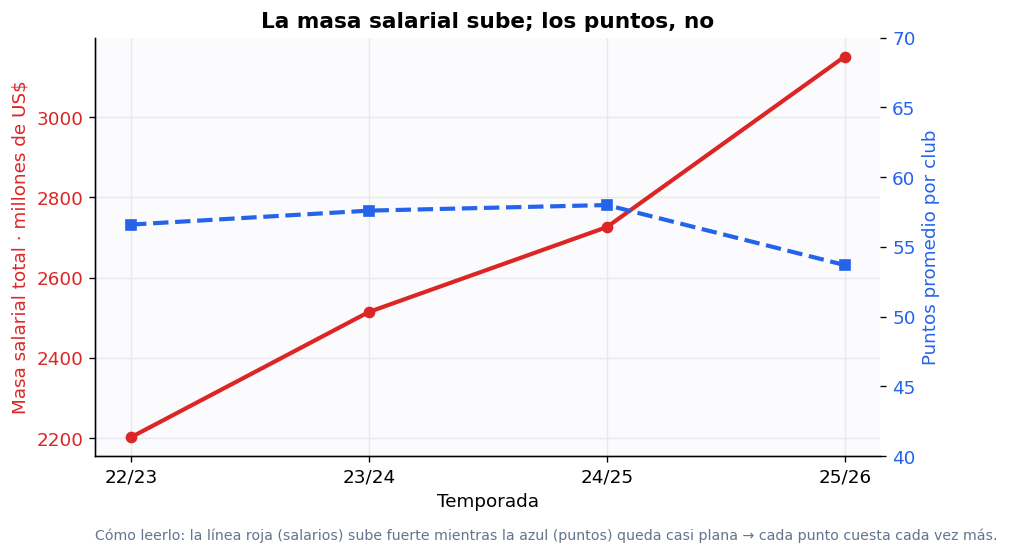

In [ ]:
fig, ax1 = plt.subplots(figsize=(8.5,4.8))
temps = list(SEAS.values())
ax1.plot(temps, resumen_temp["salarios_total_M"], "o-", color=ROJO, lw=2.5, label="Masa salarial total (17 clubes)")
ax1.set_ylabel("Masa salarial total · millones de US$", color=ROJO); ax1.tick_params(axis="y", labelcolor=ROJO)
ax2 = ax1.twinx(); ax2.grid(False)
ax2.plot(temps, resumen_temp["puntos_promedio"], "s--", color=AZUL, lw=2.5, label="Puntos promedio")
ax2.set_ylabel("Puntos promedio por club", color=AZUL); ax2.tick_params(axis="y", labelcolor=AZUL)
ax2.set_ylim(40, 70)
ax1.set_title("La masa salarial sube; los puntos, no")
ax1.set_xlabel("Temporada")
ax1.text(0,-0.2,"Cómo leerlo: la línea roja (salarios) sube fuerte mientras la azul (puntos) queda casi plana → "
         "cada punto cuesta cada vez más.", transform=ax1.transAxes, fontsize=8.5, color=GRIS)
plt.tight_layout(); plt.savefig("figuras/g1_tendencia.png", dpi=150, bbox_inches="tight"); plt.show()

**Interpretación.** La tijera es clarísima: en cuatro temporadas la masa salarial de los 17 clubes
creció **+43%** pero el rendimiento promedio se mantuvo. Como todos gastan más a la vez, el dinero extra
no se traduce en puntos (es un juego de suma cero entre ellos): **se infla el costo, no el resultado.**

### 4.b) Distribución — ¿cuánto cuestan los fichajes?  *(tipo histograma)*

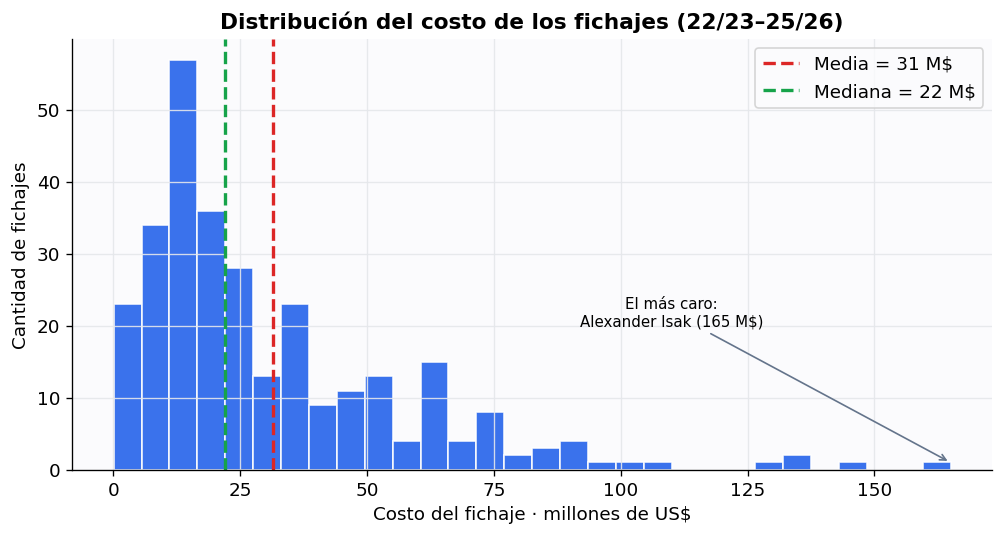

n=295 | media=31.4 | mediana=22.0 | máx=165 M$


In [ ]:
fees = compras["Coste_M$"]
fig, ax = plt.subplots(figsize=(8.5,4.6))
ax.hist(fees, bins=30, color=AZUL, edgecolor="white", alpha=0.9)
ax.axvline(fees.mean(),   color=ROJO,  ls="--", lw=2, label=f"Media = {fees.mean():.0f} M$")
ax.axvline(fees.median(), color=VERDE, ls="--", lw=2, label=f"Mediana = {fees.median():.0f} M$")
top = compras.loc[compras["Coste_M$"].idxmax()]
ax.annotate(f"El más caro:\n{top['Jugador']} ({top['Coste_M$']:.0f} M$)", xy=(top["Coste_M$"],1),
            xytext=(top["Coste_M$"]-55, 20), fontsize=9, ha="center",
            arrowprops=dict(arrowstyle="->", color=GRIS))
ax.set_title("Distribución del costo de los fichajes (22/23–25/26)")
ax.set_xlabel("Costo del fichaje · millones de US$"); ax.set_ylabel("Cantidad de fichajes"); ax.legend()
plt.tight_layout(); plt.savefig("figuras/g2_distribucion_fichajes.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"n={len(fees)} | media={fees.mean():.1f} | mediana={fees.median():.1f} | máx={fees.max():.0f} M$")

**Interpretación.** Distribución **muy sesgada a la derecha**: muchos fichajes baratos y pocos
megafichajes (hasta ~165 M$) que estiran la cola. La media supera a la mediana: el gasto de un club lo
suele marcar un par de operaciones estrella más que una política pareja.

### 4.c) Comparación entre clubes — costo por punto  *(tipo barras, promedio 4 temporadas)*

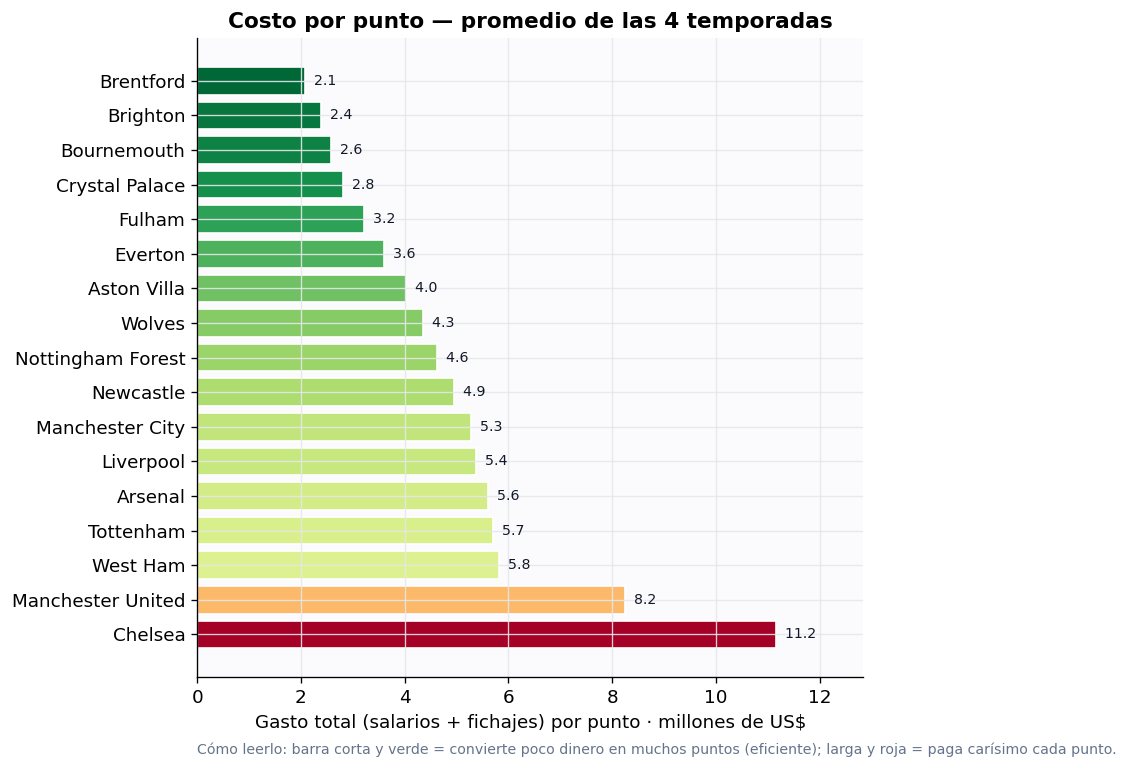

In [ ]:
orden = clubes.sort_values("Costo_por_punto")
norm = (orden["Costo_por_punto"]-orden["Costo_por_punto"].min())/(orden["Costo_por_punto"].max()-orden["Costo_por_punto"].min())
fig, ax = plt.subplots(figsize=(8.5,6.5))
ax.barh(orden["Club"].str.title(), orden["Costo_por_punto"], color=plt.cm.RdYlGn_r(norm), edgecolor="white")
etiquetar_barras_h(ax, orden["Costo_por_punto"].values, fmt="{:.1f}")
ax.set_title("Costo por punto — promedio de las 4 temporadas")
ax.set_xlabel("Gasto total (salarios + fichajes) por punto · millones de US$")
ax.set_xlim(0, orden["Costo_por_punto"].max()*1.15); ax.invert_yaxis()
ax.text(0,-0.12,"Cómo leerlo: barra corta y verde = convierte poco dinero en muchos puntos (eficiente); "
        "larga y roja = paga carísimo cada punto.", transform=ax.transAxes, fontsize=8.5, color=GRIS)
plt.tight_layout(); plt.savefig("figuras/g3_costo_por_punto.png", dpi=150, bbox_inches="tight"); plt.show()

**Interpretación.** **Brentford** (2,1 M/punto), **Brighton** (2,4) y **Bournemouth** (2,6) son las
máquinas de puntos baratos; **Chelsea** (11,2) y **Manchester United** (~8,2) los más derrochadores. El
dinero **no garantiza** rendimiento: la gestión explica gran parte de la diferencia.

### 4.d) Relación gasto–puntos sobre las 68 observaciones  *(tipo dispersión)*

> **¿Qué son `r` y `R²`?**
> - **`r` (coeficiente de correlación de Pearson)** mide cuán **alineados** están dos variables en una recta.
>   Va de **−1 a +1**: cerca de +1, cuando una sube la otra sube; cerca de 0, no hay relación lineal;
>   cerca de −1, cuando una sube la otra baja. Acá `r ≈ 0,46`: relación positiva pero **floja**.
> - **`R²` (coeficiente de determinación)** es `r` al cuadrado y se lee como **el porcentaje de la
>   variación de los puntos que el gasto logra explicar**. `R² ≈ 0,21` significa que el gasto explica
>   apenas **~21%** de las diferencias de puntos entre clubes; el **~79% restante** depende de otras
>   cosas (gestión, cuerpo técnico, lesiones, suerte). Cuanto más cerca de 1, mejor "explica" el modelo.

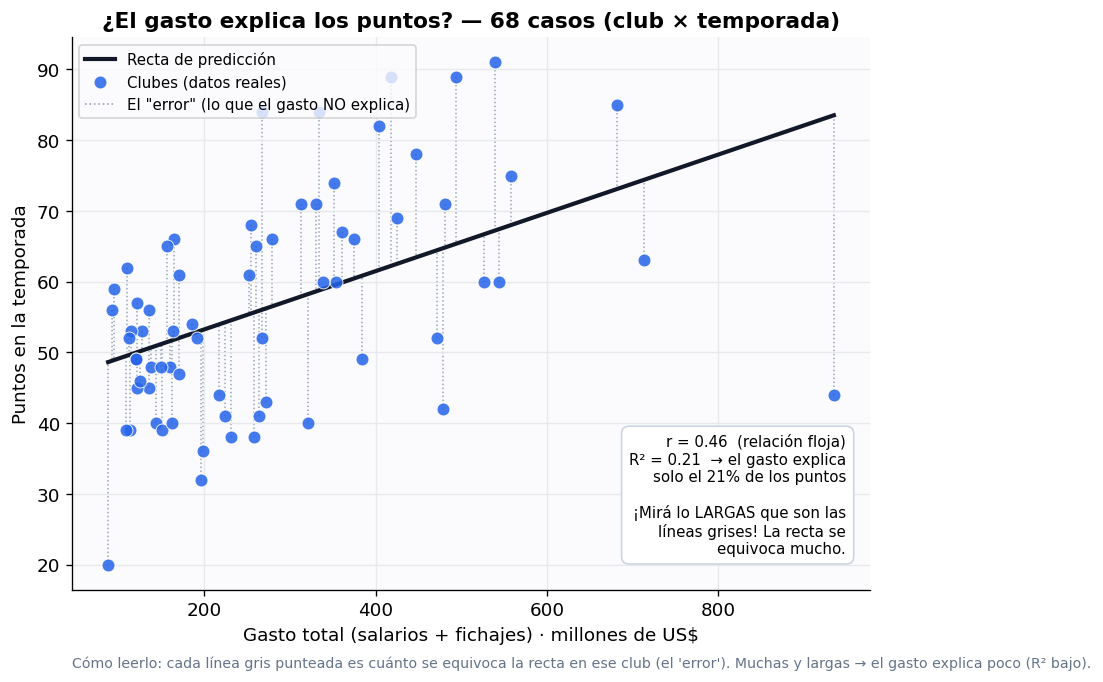

r=0.46 | R²=0.21 | cada +100 M$ ~ +4.1 puntos


In [ ]:
X = panel["Gasto_Total_M"].values; Y = panel["Puntos"].values
b1, b0 = np.polyfit(X, Y, 1); Yhat = b0 + b1*X
rr = np.corrcoef(X, Y)[0,1]

fig, ax = plt.subplots(figsize=(9,5.8))
# 1) líneas de "error" (residuos): de cada punto a la recta -> hacen VISIBLE el R²
for xi, yi, yh in zip(X, Y, Yhat):
    ax.plot([xi, xi], [yi, yh], color="#94a3b8", lw=0.9, ls=":", zorder=1)
# 2) recta de predicción
xs = np.linspace(X.min(), X.max(), 100)
ax.plot(xs, b0+b1*xs, color="#111827", lw=2.5, zorder=2, label="Recta de predicción")
# 3) puntos reales
ax.scatter(X, Y, s=60, c=AZUL, alpha=0.85, edgecolor="white", linewidth=0.6, zorder=3, label="Clubes (datos reales)")
ax.plot([], [], color="#94a3b8", lw=1, ls=":", label='El "error" (lo que el gasto NO explica)')
ax.text(0.97, 0.06,
        f"r = {rr:.2f}  (relación floja)\nR² = {rr**2:.2f}  → el gasto explica\nsolo el {rr**2*100:.0f}% de los puntos\n\n¡Mirá lo LARGAS que son las\nlíneas grises! La recta se\nequivoca mucho.",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#cbd5e1"))
ax.set_title("¿El gasto explica los puntos? — 68 casos (club × temporada)")
ax.set_xlabel("Gasto total (salarios + fichajes) · millones de US$")
ax.set_ylabel("Puntos en la temporada"); ax.legend(loc="upper left", fontsize=9)
ax.text(0,-0.14,"Cómo leerlo: cada línea gris punteada es cuánto se equivoca la recta en ese club (el 'error'). "
        "Muchas y largas → el gasto explica poco (R² bajo).", transform=ax.transAxes, fontsize=8.5, color=GRIS)
plt.tight_layout(); plt.savefig("figuras/g4_gasto_vs_puntos.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"r={rr:.2f} | R²={rr**2:.2f} | cada +100 M$ ~ +{b1*100:.1f} puntos")

**Interpretación.** La relación es **positiva pero débil**: `r ≈ 0,46` y `R² ≈ 0,21`, es decir que el
gasto explica solo **~1/5** de las diferencias de puntos. La nube está muy desparramada alrededor de la
recta; gastar ayuda en promedio, pero **deja la mayor parte sin explicar** — hay mucho margen para la
gestión (y algo de suerte). En la sección 5 vemos que, además, esa relación **no es infinita**: tiene un
punto óptimo a partir del cual gastar más rinde negativo.

### 4.e) El mapa de la eficiencia  *(tipo cuadrantes, promedio 4 temporadas)*

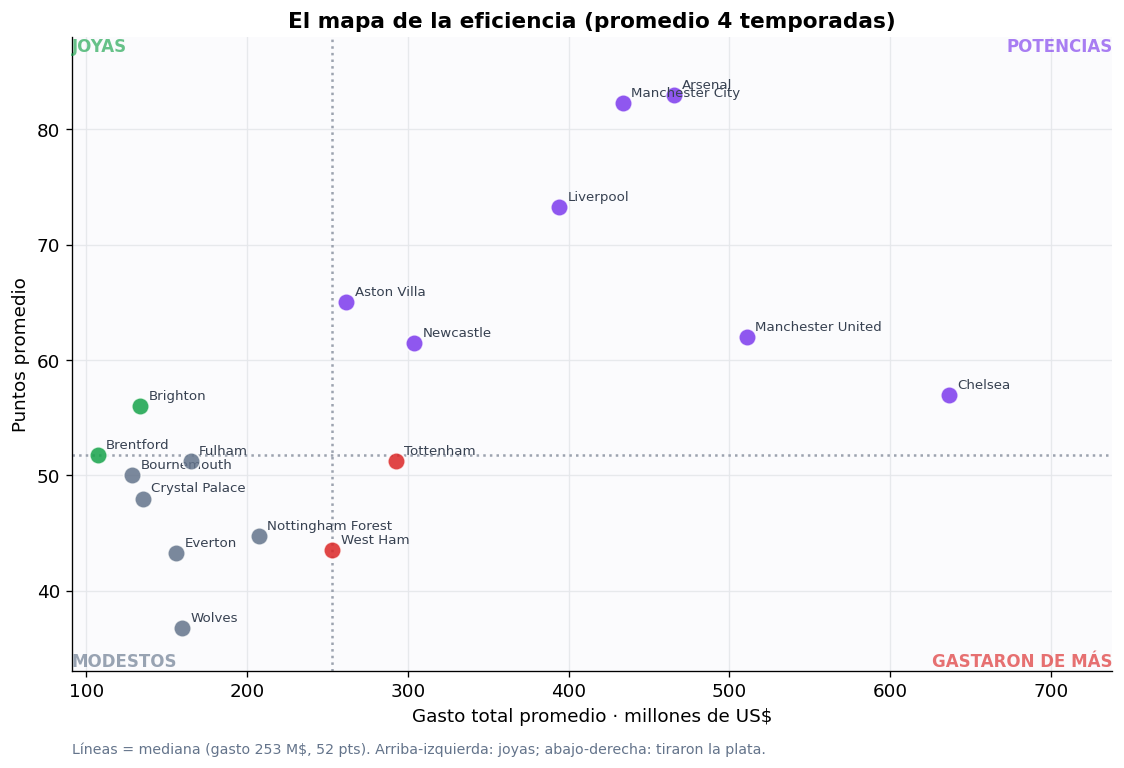

In [ ]:
# [IA] Prompt: "Scatter de cuadrantes por mediana de gasto y puntos, etiquetando clubes y coloreando por cuadrante."
mg, mp = clubes["Gasto"].median(), clubes["Puntos"].median()
def cuad(g,p):
    if g>=mg and p>=mp: return VIOLETA
    if g< mg and p>=mp: return VERDE
    if g>=mg and p< mp: return ROJO
    return GRIS
fig, ax = plt.subplots(figsize=(9.5,6.5))
for _, r in clubes.iterrows():
    ax.scatter(r["Gasto"], r["Puntos"], s=110, c=cuad(r["Gasto"],r["Puntos"]), alpha=0.85, edgecolor="white", zorder=3)
    ax.annotate(r["Club"].title(), (r["Gasto"], r["Puntos"]), xytext=(5,4), textcoords="offset points", fontsize=8, color="#374151")
ax.axvline(mg, color="#9ca3af", ls=":", lw=1.5); ax.axhline(mp, color="#9ca3af", ls=":", lw=1.5)
xmin,xmax = clubes["Gasto"].min()*0.85, clubes["Gasto"].max()*1.16
ymin,ymax = clubes["Puntos"].min()*0.9, clubes["Puntos"].max()*1.06
for tx,ty,txt,col,ha,va in [(xmax,ymax,"POTENCIAS",VIOLETA,"right","top"),(xmin,ymax,"JOYAS",VERDE,"left","top"),
                            (xmax,ymin,"GASTARON DE MÁS",ROJO,"right","bottom"),(xmin,ymin,"MODESTOS",GRIS,"left","bottom")]:
    ax.text(tx,ty,txt,ha=ha,va=va,fontsize=10,color=col,weight="bold",alpha=0.65)
ax.set_xlim(xmin,xmax); ax.set_ylim(ymin,ymax)
ax.set_title("El mapa de la eficiencia (promedio 4 temporadas)")
ax.set_xlabel("Gasto total promedio · millones de US$"); ax.set_ylabel("Puntos promedio")
ax.text(0,-0.13,f"Líneas = mediana (gasto {mg:.0f} M$, {mp:.0f} pts). Arriba-izquierda: joyas; abajo-derecha: tiraron la plata.",
        transform=ax.transAxes, fontsize=8.5, color=GRIS)
plt.tight_layout(); plt.savefig("figuras/g5_cuadrantes.png", dpi=150, bbox_inches="tight"); plt.show()

**Interpretación.** **Brighton, Bournemouth y Brentford** son las **joyas** (poco gasto, buen
rendimiento); **City, Liverpool, Arsenal** son las **potencias** que pagan y ganan; y los carísimos
**Chelsea** y **Manchester United** quedan muy a la derecha, delatando cuánto pagaron por quedarse en la
media. Abajo-izquierda, los clubes modestos que cumplen sin gastar.

## 5. Aplicación de conceptos de la materia  *(consigna 3.5)*
Núcleo en **elasticidad** (función documentada), más **estructura del gasto (salarios vs fichajes)**,
**función de costo / rendimientos decrecientes** y **margen/rentabilidad**.

### 5.1) Función documentada: elasticidad-arco

In [ ]:
# [IA] Prompt: "Función documentada de elasticidad-arco de Y respecto de X y otra que la clasifique."
def elasticidad_arco(x_ini, x_fin, y_ini, y_fin):
    '''Elasticidad-arco de Y respecto de X entre dos períodos (fórmula del punto medio):
        E = (%Δ Y)/(%Δ X), con %Δ V = (V_fin-V_ini)/((V_fin+V_ini)/2).
    >1 elástica, <1 inelástica, negativa = relación inversa, NaN si X no varía.'''
    vx = (x_fin-x_ini)/((x_fin+x_ini)/2); vy = (y_fin-y_ini)/((y_fin+y_ini)/2)
    return np.nan if vx==0 else vy/vx

def clasificar_elasticidad(e):
    '''Clasifica la elasticidad en categorías económicas.'''
    if pd.isna(e): return "indefinida"
    if e<0: return "inversa (gastó más, rindió menos)"
    if abs(e)>1: return "elástica"
    if abs(e)==1: return "unitaria"
    return "inelástica"

### 5.2) Aplicación: elasticidad puntos–gasto entre la primera y la última temporada (22/23 → 25/26)

In [ ]:
piv = panel.pivot_table(index="Club", columns="Temporada", values=["Gasto_Total_M","Puntos"])
res = []
for club in piv.index:
    e = elasticidad_arco(piv.loc[club,("Gasto_Total_M","22/23")], piv.loc[club,("Gasto_Total_M","25/26")],
                         piv.loc[club,("Puntos","22/23")], piv.loc[club,("Puntos","25/26")])
    res.append({"Club":club.title(),"Elasticidad":e,"Tipo":clasificar_elasticidad(e)})
tabE = pd.DataFrame(res).sort_values("Elasticidad", ascending=False).round(2)
display(tabE.reset_index(drop=True))
elast_glob,_ = np.polyfit(np.log(panel["Gasto_Total_M"]), np.log(panel["Puntos"]), 1)
print(f"Elasticidad global (log-log sobre el panel, n=68): {elast_glob:.2f} -> {clasificar_elasticidad(elast_glob)}")

,Club,Elasticidad,Tipo
0,Bournemouth,3.30,elástica
1,Aston Villa,1.85,elástica
2,Tottenham,0.93,inelástica
3,Wolves,0.69,inelástica
4,Manchester United,0.37,inelástica
5,West Ham,0.04,inelástica
6,Arsenal,0.02,inelástica
7,Fulham,-0.00,inelástica
8,Crystal Palace,-0.00,inelástica
9,Chelsea,-0.25,"inversa (gastó más, rindió menos)"


Elasticidad global (log-log sobre el panel, n=68): 0.24 -> inelástica


**Interpretación (elasticidad).** A nivel panel la elasticidad puntos–gasto es **~0,24: muy
inelástica** (subir el gasto 10% se asocia con ~2,4% más de puntos). Caso a caso hay de todo, incluso
**elasticidades negativas** (clubes que gastaron más y rindieron menos). Consistente con la teoría:
cuando una variable es inelástica, mover el "precio" (gasto) cambia poco la "cantidad" (puntos).

### 5.3) Estructura del gasto: ¿salarios o fichajes? (efecto Szymanski)
La economía del deporte (Szymanski) sostiene que **la masa salarial predice el rendimiento mejor que
los fichajes**. Lo testeamos en nuestro panel.

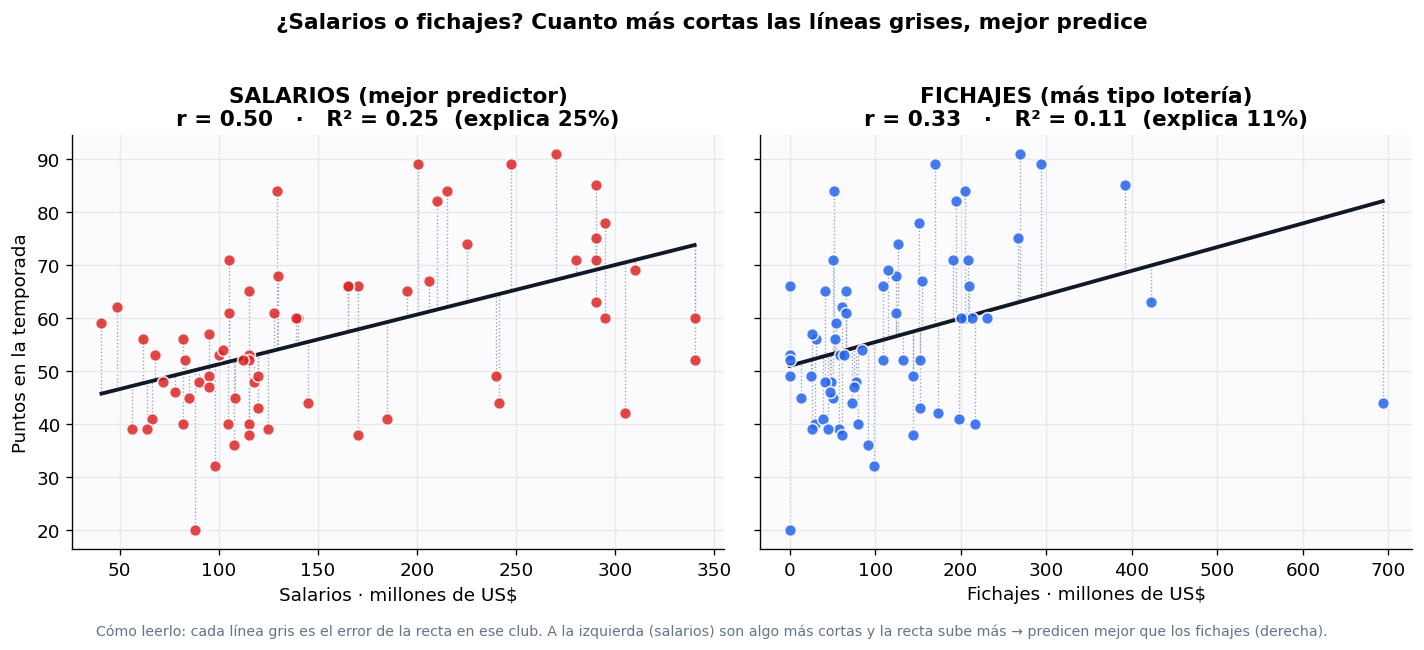

Correlación con puntos -> SALARIOS: 0.50 (R²=0.25)  |  FICHAJES: 0.33 (R²=0.11)


In [ ]:
# [IA] Prompt: "Comparación didáctica: dos paneles (salarios vs fichajes) con líneas de error (residuos)
#               para VER que los salarios predicen mejor (líneas más cortas) que los fichajes."
r_sal = np.corrcoef(panel["Salarios_M"], panel["Puntos"])[0,1]
r_fic = np.corrcoef(panel["Fichajes_M"], panel["Puntos"])[0,1]
fig, axes = plt.subplots(1,2, figsize=(12,5), sharey=True)
config = [("Salarios_M", ROJO, "SALARIOS (mejor predictor)", r_sal),
          ("Fichajes_M", AZUL, "FICHAJES (más tipo lotería)", r_fic)]
for ax,(xv,col,lab,rv) in zip(axes, config):
    X = panel[xv].values; Y = panel["Puntos"].values
    b1,b0 = np.polyfit(X, Y, 1); Yhat = b0+b1*X
    for xi,yi,yh in zip(X,Y,Yhat):                      # líneas de error (residuos)
        ax.plot([xi,xi],[yi,yh], color="#94a3b8", lw=0.8, ls=":", zorder=1)
    xs=np.linspace(X.min(),X.max(),50); ax.plot(xs,b0+b1*xs,color="#111827",lw=2.3, zorder=2)
    ax.scatter(X, Y, c=col, s=50, alpha=0.85, edgecolor="white", zorder=3)
    ax.set_title(f"{lab}\nr = {rv:.2f}   ·   R² = {rv**2:.2f}  (explica {rv**2*100:.0f}%)")
    ax.set_xlabel(xv.replace('_M',' · millones de US$'))
axes[0].set_ylabel("Puntos en la temporada")
plt.suptitle("¿Salarios o fichajes? Cuanto más cortas las líneas grises, mejor predice", y=1.02, fontsize=13, weight="bold")
fig.text(0.5, -0.02, "Cómo leerlo: cada línea gris es el error de la recta en ese club. A la izquierda (salarios) son algo "
         "más cortas y la recta sube más → predicen mejor que los fichajes (derecha).", ha="center", fontsize=8.5, color=GRIS)
plt.tight_layout(); plt.savefig("figuras/g6_salarios_vs_fichajes.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"Correlación con puntos -> SALARIOS: {r_sal:.2f} (R²={r_sal**2:.2f})  |  FICHAJES: {r_fic:.2f} (R²={r_fic**2:.2f})")

**Interpretación (Szymanski).** Tal como predice la teoría, **los salarios se asocian más fuerte con
los puntos (r ≈ 0,50) que los fichajes (r ≈ 0,34)**. Tiene lógica: el salario refleja la calidad
*sostenida* del plantel, mientras que el gasto en fichajes es más errático (un año se compra mucho, otro
poco). Para gestionar rendimiento, *quién está en nómina* importa más que *cuánto se gastó en el último mercado*.

### 5.4) ¿Hasta dónde conviene gastar? Óptimo y rendimientos decrecientes (con `sympy`)
En lugar de una recta, ajustamos con `numpy` una **parábola** `Puntos = a + b·Gasto + c·Gasto²`, que sí
puede capturar un punto de saturación. Con `sympy` calculamos la **1ª derivada** (para hallar el gasto
óptimo, donde se hace cero) y la **2ª derivada** (para confirmar, por su signo, que es un máximo).

Función ajustada (numpy):  Puntos = 31.10 + 0.1385·g + -0.000124·g²
1ra derivada  f'(g)  = 0.138529984378844 - 0.000247288409447472*g    (puntos por millón adicional)
2da derivada  f''(g) = -0.000247288409447472   = -0.000247  < 0  ->  cóncava: el óptimo es un MÁXIMO

>> GASTO ÓPTIMO ≈ 560 M$  ->  máximo ~70 puntos
>> Marginal: en 150 M$ = +0.101 pts/M$ | en 400 M$ = +0.040 | en 560 M$ ≈ 0
>> A partir de ~560 M$ la curva baja: gastar más se asocia con MENOS puntos (sobreinversión).


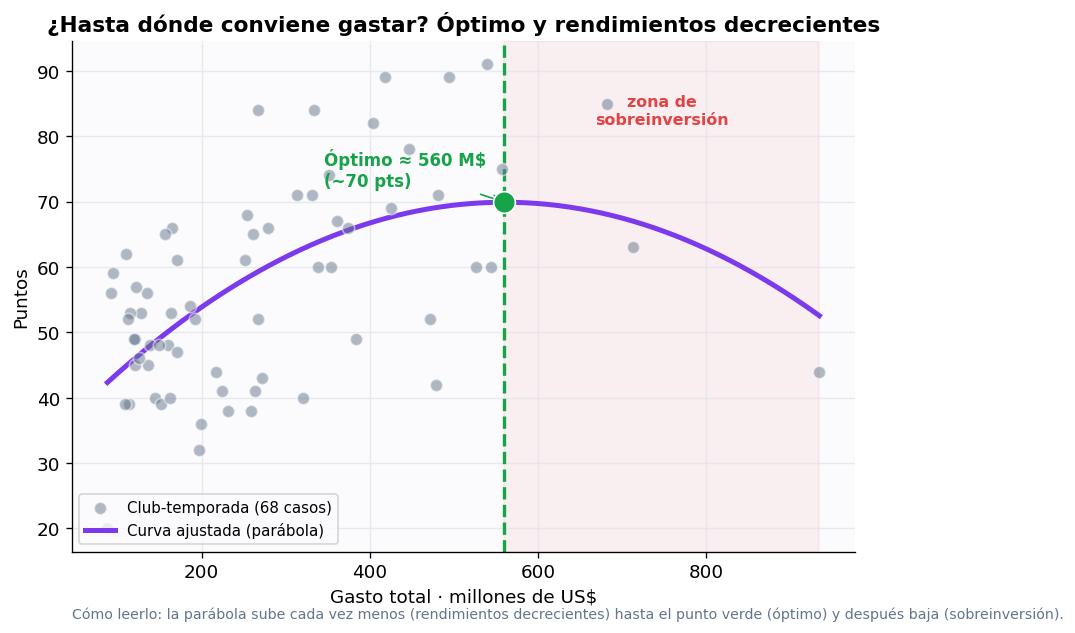

In [ ]:
# [IA] Prompt: "Ajustá una parábola puntos~gasto con numpy; con sympy obtené 1ra y 2da derivada, hallá
#               el gasto óptimo (f'=0) y confirmá con la 2da derivada que es un máximo; graficá el óptimo."
G = panel["Gasto_Total_M"].values; P = panel["Puntos"].values
c2, c1, c0 = np.polyfit(G, P, 2)                       # numpy: ajuste cuadrático

g = sp.symbols("g", positive=True)
f  = c0 + c1*g + c2*g**2                               # sympy: Puntos(Gasto)
f1 = sp.diff(f, g)                                     # 1ra derivada = puntos por M$ adicional
f2 = sp.diff(f, g, 2)                                  # 2da derivada = curvatura
g_opt = float(sp.solve(sp.Eq(f1, 0), g)[0])           # gasto óptimo: f'(g)=0
p_opt = float(f.subs(g, g_opt))

print(f"Función ajustada (numpy):  Puntos = {c0:.2f} + {c1:.4f}·g + {c2:.6f}·g²")
print("1ra derivada  f'(g)  =", f1, "   (puntos por millón adicional)")
print("2da derivada  f''(g) =", f2, f"  = {float(f2):.6f}  < 0  ->  cóncava: el óptimo es un MÁXIMO")
print(f"\n>> GASTO ÓPTIMO ≈ {g_opt:.0f} M$  ->  máximo ~{p_opt:.0f} puntos")
print(f">> Marginal: en 150 M$ = +{float(f1.subs(g,150)):.3f} pts/M$ | en 400 M$ = +{float(f1.subs(g,400)):.3f} | en {g_opt:.0f} M$ ≈ 0")
print(f">> A partir de ~{g_opt:.0f} M$ la curva baja: gastar más se asocia con MENOS puntos (sobreinversión).")

fig, ax = plt.subplots(figsize=(8.8,5.4))
ax.scatter(G, P, s=55, c=GRIS, alpha=0.5, edgecolor="white", zorder=3, label="Club-temporada (68 casos)")
xs = np.linspace(G.min(), G.max(), 200)
ax.plot(xs, c0+c1*xs+c2*xs**2, color=VIOLETA, lw=3, zorder=2, label="Curva ajustada (parábola)")
ax.axvspan(g_opt, G.max(), color=ROJO, alpha=0.06)
ax.axvline(g_opt, color=VERDE, ls="--", lw=2)
ax.scatter([g_opt], [p_opt], s=170, c=VERDE, zorder=5, edgecolor="white")
ax.annotate(f"Óptimo ≈ {g_opt:.0f} M$\n(~{p_opt:.0f} pts)", (g_opt, p_opt), xytext=(g_opt-215, p_opt+2.5),
            fontsize=10, weight="bold", color=VERDE, arrowprops=dict(arrowstyle="->", color=VERDE))
ax.text(g_opt+(G.max()-g_opt)/2, p_opt+12, "zona de\nsobreinversión", ha="center", color=ROJO, fontsize=9.5, weight="bold", alpha=0.85)
ax.set_title("¿Hasta dónde conviene gastar? Óptimo y rendimientos decrecientes")
ax.set_xlabel("Gasto total · millones de US$"); ax.set_ylabel("Puntos"); ax.legend(loc="lower left", fontsize=9)
ax.text(0,-0.13,"Cómo leerlo: la parábola sube cada vez menos (rendimientos decrecientes) hasta el punto verde "
        "(óptimo) y después baja (sobreinversión).", transform=ax.transAxes, fontsize=8.5, color=GRIS)
plt.tight_layout(); plt.savefig("figuras/g7_optimo_gasto.png", dpi=150, bbox_inches="tight"); plt.show()

**Interpretación (óptimo y 2ª derivada).** La **1ª derivada `f'(g)`** es el *producto marginal del
dinero* (cuántos puntos suma el próximo millón): empieza alta y **va cayendo** — eso son los rendimientos
decrecientes. Se hace **cero en g\* ≈ 560 M$**, el **gasto óptimo**, donde los puntos se maximizan (~70).
La **2ª derivada `f''(g)` es negativa y constante (≈ 0,00025)**: confirma que la curva es **cóncava**, o
sea que el punto crítico es un **máximo** (no un mínimo) y que los rendimientos decrecen en todo el tramo.
Pasado el óptimo, gastar más se asocia con **menos** puntos; en los datos el único club en esa zona es
**Chelsea (640 M)** — la marca de la *sobreinversión*. **Moraleja:** el dinero rinde hasta un techo; de
ahí en más, lo que falta es gestión.

### Optimización del presupuesto con programación lineal (`pulp`)
Pregunta de gestión: con un presupuesto fijo, ¿cuánto poner en **salarios** y cuánto en **fichajes**?
Lo resolvemos como **programación lineal**: maximizar los puntos esperados según la regresión múltiple
`Puntos ≈ β_sal·Salarios + β_fic·Fichajes`, exigiendo invertir algo en ambos (mínimo 15% en fichajes,
máximo 90% en salarios).

In [ ]:
# [IA] Prompt: "Con pulp, repartí un presupuesto fijo entre salarios y fichajes para maximizar los puntos
#               esperados usando los coeficientes de una regresión múltiple; mostrá la asignación óptima."
# Coeficientes de Puntos ~ Salarios + Fichajes (numpy)
Xm = np.column_stack([panel["Salarios_M"], panel["Fichajes_M"], np.ones(len(panel))])
beta_sal, beta_fic, intercepto = np.linalg.lstsq(Xm, panel["Puntos"].values, rcond=None)[0]
print(f"Aporte estimado por M$ -> salarios: {beta_sal:.4f} pts | fichajes: {beta_fic:.4f} pts")

PRES = 300  # presupuesto a repartir (M$), valor de ejemplo
prob = pulp.LpProblem("asignacion_presupuesto", pulp.LpMaximize)
S = pulp.LpVariable("Salarios", lowBound=0)
F = pulp.LpVariable("Fichajes", lowBound=0)
prob += beta_sal*S + beta_fic*F          # objetivo: puntos esperados
prob += S + F <= PRES                     # restricción de presupuesto
prob += F >= 0.15*PRES                    # hay que invertir algo en fichajes
prob += S <= 0.90*PRES                    # no todo puede ir a salarios
prob.solve(pulp.PULP_CBC_CMD(msg=0))
pts_esp = intercepto + beta_sal*S.value() + beta_fic*F.value()
print(f"\nPresupuesto = {PRES} M$  ->  asignación óptima ({pulp.LpStatus[prob.status]}):")
print(f"  Salarios: {S.value():.0f} M$  ({S.value()/PRES*100:.0f}%)")
print(f"  Fichajes: {F.value():.0f} M$  ({F.value()/PRES*100:.0f}%)")
print(f"  Puntos esperados: {pts_esp:.1f}")

Aporte estimado por M$ -> salarios: 0.0841 pts | fichajes: 0.0134 pts

Presupuesto = 300 M$  ->  asignación óptima (Optimal):
  Salarios: 255 M$  (85%)
  Fichajes: 45 M$  (15%)
  Puntos esperados: 63.8


**Interpretación (`pulp`).** Como cada millón en **salarios** aporta más puntos que en fichajes, la
solución óptima **carga el presupuesto al máximo en salarios y deja el mínimo en fichajes (≈ 85% / 15%)**.
Es el efecto Szymanski traducido a una decisión de gestión: ante un peso disponible, *conviene sostener un
buen plantel en nómina antes que apostar al golpe de mercado*. Es un modelo ilustrativo y lineal —en la
realidad hay topes salariales, fair-play financiero y los rendimientos decrecientes que vimos arriba que
lo matizan.

### 5.5) Margen, rentabilidad y objetivo deportivo
Clasificamos a los 17 por **objetivo**, usando sus **puntos promedio** de las 4 temporadas:
**Pelea arriba** (≥65), **Media tabla / Europa** (50–64) y **Lucha por permanecer** (<50).

,clubes,gasto_prom,puntos_prom,costo_punto
Objetivo,,,,
Pelea arriba,4,388.8,75.9,5.1
Media tabla / Europa,8,284.7,55.1,5.0
Lucha por permanecer,5,182.2,43.2,4.2


  Pelea arriba: Arsenal, Aston Villa, Liverpool, Manchester City
  Media tabla / Europa: Bournemouth, Brentford, Brighton, Chelsea, Fulham, Manchester United, Newcastle, Tottenham
  Lucha por permanecer: Crystal Palace, Everton, Nottingham Forest, West Ham, Wolves


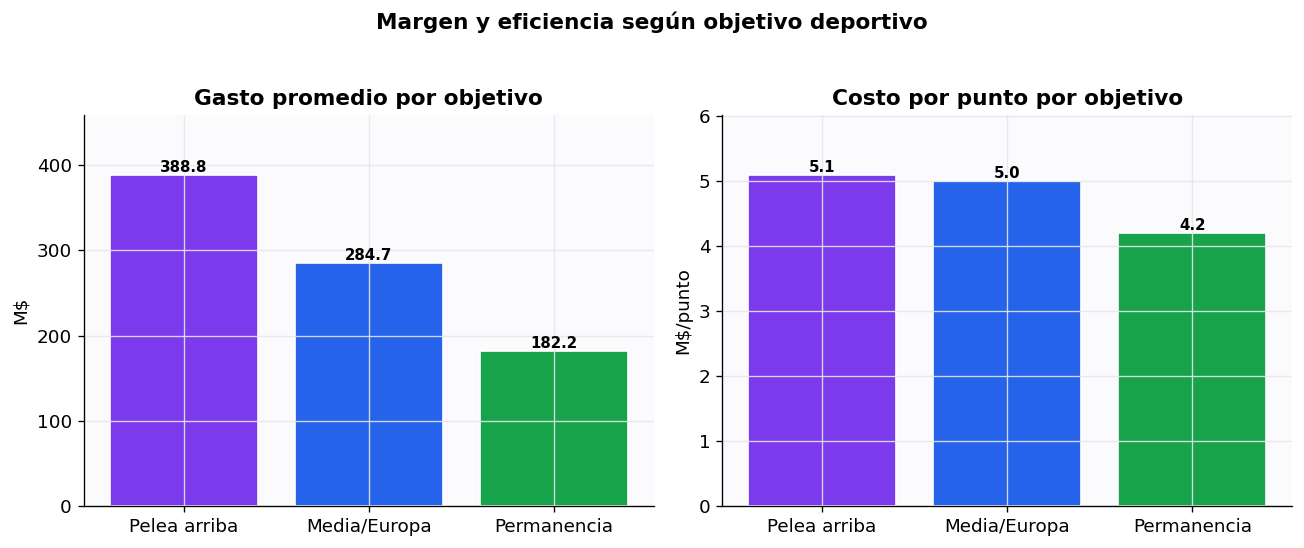


Más rentables (puntos por millón):


,Club,Gasto,Puntos,Puntos_por_M
0,BRENTFORD,107.08,51.75,0.48
1,BRIGHTON,133.59,56.00,0.42
2,BOURNEMOUTH,128.70,50.00,0.39
3,CRYSTAL PALACE,135.32,48.00,0.35
4,FULHAM,165.05,51.25,0.31


In [ ]:
def objetivo(pts_prom):
    '''Objetivo deportivo según puntos promedio de las 4 temporadas.'''
    if pts_prom >= 65: return "Pelea arriba"
    if pts_prom >= 50: return "Media tabla / Europa"
    return "Lucha por permanecer"
clubes["Objetivo"] = clubes["Puntos"].apply(objetivo)
orden_o = ["Pelea arriba","Media tabla / Europa","Lucha por permanecer"]
res_o = (clubes.groupby("Objetivo").agg(clubes=("Club","count"), gasto_prom=("Gasto","mean"),
         puntos_prom=("Puntos","mean"), costo_punto=("Costo_por_punto","mean")).reindex(orden_o).round(1))
display(res_o)
for o in orden_o: print(f"  {o}: " + ", ".join(clubes.loc[clubes['Objetivo']==o,'Club'].str.title()))

fig, axes = plt.subplots(1,2, figsize=(11,4.4)); cols=[VIOLETA,AZUL,VERDE]; lab=["Pelea arriba","Media/Europa","Permanencia"]
for ax,(ti,se,yl) in zip(axes,[("Gasto promedio por objetivo",res_o["gasto_prom"],"M$"),
                                ("Costo por punto por objetivo",res_o["costo_punto"],"M$/punto")]):
    bars=ax.bar(range(3), se, color=cols, edgecolor="white")
    for r,v in zip(bars,se): ax.text(r.get_x()+r.get_width()/2, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9, weight="bold")
    ax.set_title(ti); ax.set_ylabel(yl); ax.set_xticks(range(3)); ax.set_xticklabels(lab); ax.set_ylim(0, se.max()*1.18)
plt.suptitle("Margen y eficiencia según objetivo deportivo", y=1.03, fontsize=13, weight="bold")
plt.tight_layout(); plt.savefig("figuras/g8_objetivo.png", dpi=150, bbox_inches="tight"); plt.show()

clubes["Participacion_%"] = 100*clubes["Gasto"]/clubes["Gasto"].sum()
print("\nMás rentables (puntos por millón):")
display(clubes.sort_values("Puntos_por_M", ascending=False)[["Club","Gasto","Puntos","Puntos_por_M"]].head(5).round(2).reset_index(drop=True))

**Interpretación (margen/objetivo).** Curiosamente, el costo por punto es **parejo entre la pelea de
arriba (5,1) y la zona media (~5,2)**, y hasta **más barato en la lucha por permanecer (~4,2)**: los
clubes chicos no se pueden dar el lujo de derrochar, así que cada peso rinde. Medido como **puntos por
millón**, los más rentables son los de presupuesto chico (**Brentford, Bournemouth, Brighton**). El
gasto está, además, muy concentrado en pocos clubes.

## 6. La trampa de los ascendidos

El dato más llamativo del período: en **2023/24 y 2024/25 los tres equipos ascendidos descendieron**
(seis equipos seguidos volvieron a Segunda al primer intento), dejando intacto el núcleo de 17. ¿Por qué?
Comparamos el gasto de los clubes que **descendieron** (con datos en 21/22 y 22/23) contra los 17 estables.

Clubes que terminaron descendiendo (datos disponibles):


,Club,Temp,Gasto,Puntos
0,Burnley,21,102.0,35.0
1,Leeds,21,94.0,38.0
2,Leeds,22/23,243.0,31.0
3,Leicester,21,165.0,52.0
4,Leicester,22/23,154.0,34.0
5,Norwich,21,108.0,22.0
6,Southampton,21,134.0,40.0
7,Southampton,22/23,233.0,25.0
8,Watford,21,98.0,23.0


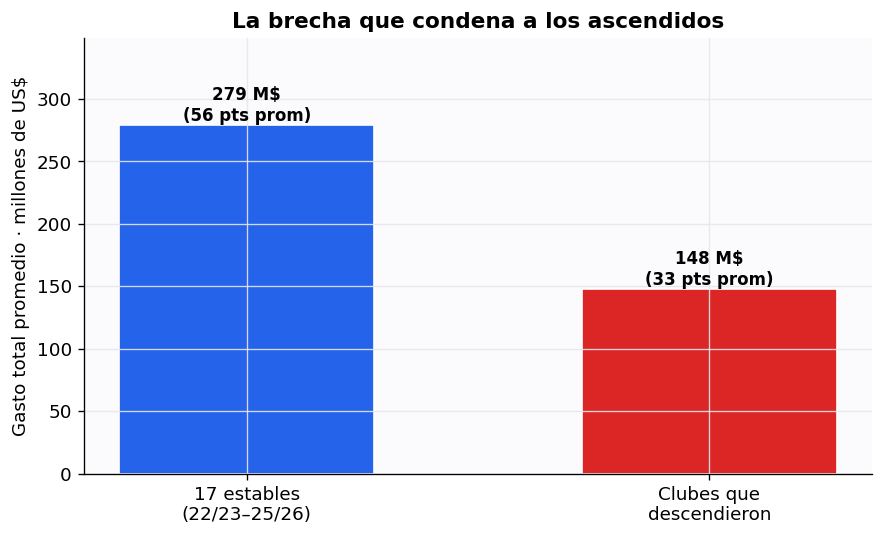


Los estables gastan ~1.9x más que los que descienden.


In [ ]:
# [IA] Prompt: "Compará el gasto promedio de los clubes que descendieron vs los 17 estables para ilustrar la brecha."
desc = ["BURNLEY","LEEDS","LEICESTER","SOUTHAMPTON","NORWICH","WATFORD"]
filas_d = []
for _, r in maestro[maestro["CLUBES"].isin(desc)].iterrows():
    for yr in ["21","22"]:
        pt = pd.to_numeric(pd.Series([r[f"PUNTOS_{yr}"]]), errors="coerce").iloc[0]
        if pt and pt>0:
            sal = parsear_dinero(pd.Series([r[f"SALARIOS_AÑO_{yr}"]])).iloc[0]/1e6
            fic = pd.to_numeric(pd.Series([r[f"GASTOS_FICHAJES_{yr}_M$"]]), errors="coerce").iloc[0]
            filas_d.append({"Club":r["CLUBES"].title(),"Temp":SEAS.get(yr,yr),"Gasto":sal+fic,"Puntos":pt})
descendidos = pd.DataFrame(filas_d)
print("Clubes que terminaron descendiendo (datos disponibles):"); display(descendidos.round(0))

g_estables = panel["Gasto_Total_M"].mean(); p_estables = panel["Puntos"].mean()
g_desc = descendidos["Gasto"].mean(); p_desc = descendidos["Puntos"].mean()
fig, ax = plt.subplots(figsize=(7.5,4.6))
bars = ax.bar(["17 estables\n(22/23–25/26)","Clubes que\ndescendieron"], [g_estables, g_desc],
              color=[AZUL, ROJO], edgecolor="white", width=0.55)
for r,v,pt in zip(bars,[g_estables,g_desc],[p_estables,p_desc]):
    ax.text(r.get_x()+r.get_width()/2, v, f"{v:.0f} M$\n({pt:.0f} pts prom)", ha="center", va="bottom", fontsize=10, weight="bold")
ax.set_title("La brecha que condena a los ascendidos")
ax.set_ylabel("Gasto total promedio · millones de US$"); ax.set_ylim(0, g_estables*1.25)
plt.tight_layout(); plt.savefig("figuras/g9_trampa_ascendidos.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"\nLos estables gastan ~{g_estables/g_desc:.1f}x más que los que descienden.")

**Interpretación.** La brecha es brutal: los 17 estables gastan en promedio **280 M** y suman 56
puntos, mientras los clubes que terminaron descendiendo gastaron **148 M** (la mitad) y promediaron
**~33 puntos**. Y el detalle más interesante: **gastar más tampoco los salvó** — Leeds (243 M) y
Southampton (233 M) hicieron grandes desembolsos para sobrevivir en 22/23 y **igual descendieron**. La
*trampa de los ascendidos* es estructural: llegan con un plantel y unas estructuras muy por debajo del
piso de la Premier, y un mercado de pánico rara vez alcanza para cerrar esa distancia en una temporada.
Por eso en 23/24 y 24/25 los seis ascendidos volvieron a bajar.

## 7. Descubrimientos y datos curiosos

In [ ]:
def top_col(sheet, col):
    e = pd.read_excel(xls, sheet); v = pd.to_numeric(e[col], errors="coerce")
    i = v.idxmax(); return e.loc[i,"Jugador"], v.loc[i]
big = compras.loc[compras["Coste_M$"].idxmax()]
posc = compras.groupby("Posición")["Coste_M$"].mean().sort_values(ascending=False)
gast = compras.groupby("Club_Involucrado")["Coste_M$"].sum().sort_values(ascending=False)
ga_j, ga_v = top_col("ESTADISTICAS_21","goalsAssistsSum"); rt_j, rt_v = top_col("ESTADISTICAS_21","rating")
print("⚽ DATOS CURIOSOS — Premier 21/22 → 25/26"); print("-"*60)
print(f"💰 Fichaje más caro (5 temp): {big['Jugador']} → {big['Club_Involucrado'].title()} ({big['Coste_M$']:.0f} M$, {big['Temporada']})")
print(f"🎯 Posición más cara:        {posc.index[0]} ({posc.iloc[0]:.0f} M$)  |  más barata: {posc.index[-1]} ({posc.iloc[-1]:.0f} M$)")
print(f"🛒 Club más gastador:        {gast.index[0].title()} ({gast.iloc[0]:.0f} M$ en fichajes)")
print(f"📈 Total compras 5 temp:     {len(compras)} operaciones por {compras['Coste_M$'].sum():.0f} M$")
print(f"🏅 Más eficiente (4 temp):   {clubes.loc[clubes['Costo_por_punto'].idxmin(),'Club'].title()} ({clubes['Costo_por_punto'].min():.1f} M$/punto)")
print(f"🐌 Menos eficiente:          {clubes.loc[clubes['Costo_por_punto'].idxmax(),'Club'].title()} ({clubes['Costo_por_punto'].max():.1f} M$/punto)")
print("\nFichaje más caro por temporada:")
for t in ["21/22","22/23","23/24","24/25","25/26"]:
    s = compras[compras["Temporada"]==t]
    if len(s):
        b = s.loc[s["Coste_M$"].idxmax()]; print(f"  {t}: {b['Jugador']} ({b['Coste_M$']:.0f} M$, {b['Club_Involucrado'].title()})")

⚽ DATOS CURIOSOS — Premier 21/22 → 25/26
------------------------------------------------------------
💰 Fichaje más caro (5 temp): Alexander Isak → Liverpool Fc (165 M$, 25/26)
🎯 Posición más cara:        Delantero centro (42 M$)  |  más barata: Portero (20 M$)
🛒 Club más gastador:        Chelsea (1348 M$ en fichajes)
📈 Total compras 5 temp:     295 operaciones por 9261 M$
🏅 Más eficiente (4 temp):   Brentford (2.1 M$/punto)
🐌 Menos eficiente:          Chelsea (11.2 M$/punto)
👟 Goles+asistencias 21/22:  Mohamed Salah = 36
⭐ Mejor rating 21/22:       Kevin De Bruyne = 7.78

Fichaje más caro por temporada:
  21/22: Ben White (64 M$, Arsenal)
  22/23: Enzo Fernández (133 M$, Chelsea)
  23/24: Declan Rice (133 M$, Arsenal)
  24/25: Pedro Neto (69 M$, Chelsea)
  25/26: Alexander Isak (165 M$, Liverpool Fc)


**Lo más jugoso.** El récord del período es **Alexander Isak (~165 M$)**. Los **delanteros centro** son
la posición más cara y los **arqueros** la más barata. **Chelsea** lideró el gasto en fichajes. Y aunque
la base es financiera, los nombres aparecen: **Salah** dominó goles+asistencias y **De Bruyne** el mejor
rating de 21/22.

## 8. Reflexión sobre el uso de IA  *(para el informe — consigna §6)*
- **Dónde se usó IA.** Estructura, funciones documentadas, tipos de gráfico y redacción (celdas `# [IA] Prompt`).
- **A cargo del grupo.** Elección del tema y la pregunta, **detección de problemas de calidad** (salarios
  como texto, traspasos 22 con columnas reordenadas, la liga de 17 vs 20), validación de que los puntos
  fueran reales (City 93/89/91, Liverpool 84 campeón 24/25) y la **interpretación económica**.
- **Revisión.** Cada integrante relee y contrasta las afirmaciones con las salidas antes de la entrega.

---
## 9. Conclusiones

### 9.1) Síntesis de los hallazgos
1. **El dinero ayuda pero no compra puntos.** En el panel de 68 casos, el gasto explica solo ~1/5 del
   rendimiento (R² ≈ 0,22) y la elasticidad es **inelástica (0,24)**.
2. **Los salarios pesan más que los fichajes** (r ≈ 0,50 vs 0,34): la calidad *sostenida* del plantel
   predice mejor que el último mercado (efecto Szymanski).
3. **Inflación sin resultados.** La masa salarial de los 17 creció **+43%** en cuatro temporadas con
   puntos planos: el "precio del punto" sube.
4. **La eficiencia manda.** Costo por punto de ~2,1 M (Brentford) a ~11,2M(Chelsea). El ajuste
   cuadrático muestra rendimientos decrecientes con un **óptimo de gasto ≈ 560 M** (2ª derivada negativa
   → es un máximo): más allá de ese punto, gastar más se asocia con *menos* puntos (zona Chelsea).
5. **La trampa de los ascendidos.** Los que descienden gastan la mitad (~148 vs ~280 M$) y, aun cuando
   se estiran (Leeds, Southampton), igual bajan: en 23/24 y 24/25 los seis ascendidos volvieron a Segunda.
6. **Por objetivo,** el costo por punto es parejo arriba y en el medio, y más barato entre los que pelean
   por no descender (no pueden derrochar).

### 9.2) Limitaciones
(i) Una sola liga; (ii) los stats por jugador solo cubren 21/22–22/23 y tienen esquema irregular, por lo
que el foco fue el nivel club; (iii) sin variables de control, las medidas son descriptivas, no causales;
(iv) de los clubes ascendidos solo hay datos de algunos (los del período 21/22–22/23).

### 9.3) Extensiones posibles
Sumar **valores de mercado de Transfermarkt** por jugador para medir rentabilidad individual; modelar el
panel con efectos fijos por club/temporada; incorporar datos de los ascendidos recientes.

### 9.4) Conclusión objetiva
> Sobre la base analizada (Premier League, 17 clubes en 4 temporadas, 2022/23–2025/26), **no se verifica
> que un mayor gasto determine un mejor rendimiento deportivo**: la asociación gasto–puntos es débil
> (R² ≈ 0,22) e inelástica (~0,24), con rendimientos marginales decrecientes. Entre los componentes del
> gasto, **los salarios predicen el rendimiento mejor que los fichajes**, y el costo del punto creció por
> la inflación salarial sin mejora en los resultados. La variable que mejor distingue a los clubes es su
> **eficiencia**, no el volumen de gasto. Finalmente, la **brecha financiera estructural** entre el núcleo
> estable y los ascendidos explica por qué estos últimos descienden de forma recurrente. Los resultados
> son consistentes con la literatura económica del deporte y se presentan como descriptivos.